<a href="https://colab.research.google.com/github/tusharj23/ProteinBERT/blob/main/notebooks/ProtBERT_without_pretraining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install tape-proteins
!wget https://s3.amazonaws.com/songlabdata/proteindata/data_pytorch/secondary_structure.tar.gz
!mkdir -p data
!tar -xzf secondary_structure.tar.gz -C data

--2026-03-21 13:49:11--  https://s3.amazonaws.com/songlabdata/proteindata/data_pytorch/secondary_structure.tar.gz
Resolving s3.amazonaws.com (s3.amazonaws.com)... 52.216.48.64, 54.231.166.152, 16.15.223.179, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|52.216.48.64|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 251794897 (240M) [application/x-tar]
Saving to: ‘secondary_structure.tar.gz’

secondary_structure 100%[===================>] 240.13M  12.6MB/s    in 21s     

2026-03-21 13:49:34 (11.3 MB/s) - ‘secondary_structure.tar.gz’ saved [251794897/251794897]



Detected vocab size: 29

MODEL ARCHITECTURE

Layer                    Activation Volume        Parameters     
Input                    16 x 512                 0              
Embedding                torch.Size([16, 512, 256])7424           
LayerNorm                torch.Size([16, 512, 256])512            
Positional Encoding      torch.Size([16, 512, 256])0              
ProteinBERT Blocks       torch.Size([16, 512, 256])1581056        
Linear                   torch.Size([16, 512, 3]) 771            
Epoch 1/20 | Train Loss: 0.8562 | Train Acc: 0.6156 | Val Loss: 0.7650 | Val Acc: 0.6633
Epoch 2/20 | Train Loss: 0.7573 | Train Acc: 0.6669 | Val Loss: 0.7516 | Val Acc: 0.6692
Epoch 3/20 | Train Loss: 0.7339 | Train Acc: 0.6787 | Val Loss: 0.7442 | Val Acc: 0.6751
Epoch 4/20 | Train Loss: 0.7216 | Train Acc: 0.6850 | Val Loss: 0.7122 | Val Acc: 0.6894
Epoch 5/20 | Train Loss: 0.7080 | Train Acc: 0.6917 | Val Loss: 0.7187 | Val Acc: 0.6852
Epoch 6/20 | Train Loss: 0.7034 | Train Acc:

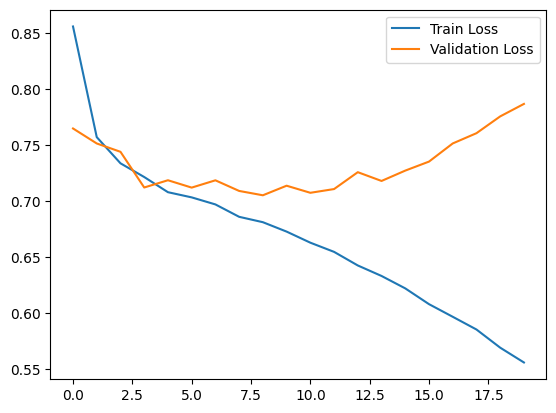

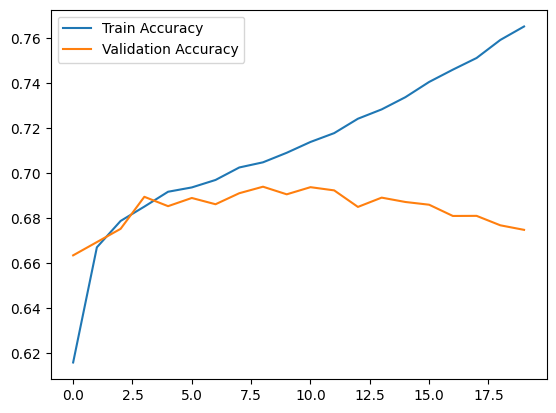

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import math
import matplotlib.pyplot as plt
from tape.datasets import SecondaryStructureDataset


# Hyperparameters
LR = 1e-3
MAX_LEN = 512
BATCH_SIZE = 16
EPOCHS = 20
d_model = 256
layers = 4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Dataset Wrapper
class TapeDataset(Dataset):

    def __init__(self, split):

        self.dataset = SecondaryStructureDataset(
            data_path="./data",
            split=split
        )

    def __len__(self):

        return len(self.dataset)

    def __getitem__(self, idx):

        token_ids, input_mask, labels = self.dataset[idx]

        seq = torch.tensor(token_ids)
        label = torch.tensor(labels)

        seq = seq[:MAX_LEN]
        label = label[:MAX_LEN]

        if len(seq) < MAX_LEN:

            pad_len = MAX_LEN - len(seq)

            seq = torch.cat([
                seq,
                torch.zeros(pad_len).long()
            ])

            label = torch.cat([
                label,
                torch.full((pad_len,), -1).long()
            ])

        return seq, label


# Load Dataset
train_dataset = TapeDataset("train")
valid_dataset = TapeDataset("valid")
test_dataset = TapeDataset("cb513")

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE
)


# Detect Vocabulary Size
max_token = 0

for i in range(500):

    token_ids, _, _ = train_dataset.dataset[i]

    max_token = max(max_token, max(token_ids))

VOCAB_SIZE = max_token + 1

print("Detected vocab size:", VOCAB_SIZE)


# Positional Encoding
class PositionalEncoding(nn.Module):

    def __init__(self, d_model, max_len=1000):

        super().__init__()

        pe = torch.zeros(max_len, d_model)

        position = torch.arange(0, max_len).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2)
            * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        pe = pe.unsqueeze(0)

        self.register_buffer("pe", pe)

    def forward(self, x):

        return x + self.pe[:, :x.size(1)]



# ProteinBERT BLOCK


class ProteinBERTBlock(nn.Module):

    def __init__(self, d_model):

        super().__init__()

        self.local_conv = nn.Conv1d(
            d_model,
            d_model,
            kernel_size=3,
            padding=1
        )

        self.local_norm = nn.LayerNorm(d_model)

        self.global_dense = nn.Linear(
            d_model,
            d_model
        )

        self.global_norm = nn.LayerNorm(d_model)

        self.local_to_global = nn.Linear(
            d_model,
            d_model
        )

        self.global_to_local = nn.Linear(
            d_model,
            d_model
        )

        self.activation = nn.GELU()


    def forward(self, local_repr, global_repr):

        # Local branch
        local = local_repr.transpose(1, 2)

        local = self.local_conv(local)

        local = local.transpose(1, 2)

        local = self.activation(local)

        local = self.local_norm(
            local + local_repr
        )


        # Global branch
        global_update = self.global_dense(
            global_repr
        )

        global_update = self.activation(
            global_update
        )

        global_repr = self.global_norm(
            global_repr + global_update
        )


        # Cross interaction
        global_from_local = self.local_to_global(
            local.mean(dim=1)
        )

        global_repr = global_repr + global_from_local


        local_from_global = self.global_to_local(
            global_repr.unsqueeze(1)
        )

        local = local + local_from_global


        return local, global_repr



# ProteinBERT MODEL


class ProteinBERT(nn.Module):

    def __init__(self, vocab_size):

        super().__init__()

        self.embedding = nn.Embedding(
            vocab_size,
            d_model
        )

        self.norm = nn.LayerNorm(d_model)

        self.pos_encoding = PositionalEncoding(
            d_model
        )

        self.global_embedding = nn.Parameter(
            torch.randn(1, d_model)
        )

        self.blocks = nn.ModuleList([

            ProteinBERTBlock(d_model)

            for _ in range(layers)

        ])

        self.fc = nn.Linear(
            d_model,
            3
        )


    def forward(self, x):

        x = self.embedding(x)

        x = self.norm(x)

        x = self.pos_encoding(x)


        global_repr = self.global_embedding.expand(
            x.size(0),
            -1
        )


        for block in self.blocks:

            x, global_repr = block(
                x,
                global_repr
            )


        x = self.fc(x)

        return x


# Model Initialization
model = ProteinBERT(
    VOCAB_SIZE
).to(device)



# MODEL SUMMARY TABLE


def print_model_table(model):

    x = torch.zeros(
        BATCH_SIZE,
        MAX_LEN
    ).long().to(device)

    print("\nMODEL ARCHITECTURE\n")

    print("{:<25}{:<25}{:<15}".format(
        "Layer",
        "Activation Volume",
        "Parameters"
    ))

    print("{:<25}{:<25}{:<15}".format(
        "Input",
        f"{BATCH_SIZE} x {MAX_LEN}",
        "0"
    ))

    x = model.embedding(x)

    params = model.embedding.weight.numel()

    print("{:<25}{:<25}{:<15}".format(
        "Embedding",
        f"{x.shape}",
        params
    ))

    x = model.norm(x)

    params = sum(
        p.numel()
        for p in model.norm.parameters()
    )

    print("{:<25}{:<25}{:<15}".format(
        "LayerNorm",
        f"{x.shape}",
        params
    ))

    x = model.pos_encoding(x)

    print("{:<25}{:<25}{:<15}".format(
        "Positional Encoding",
        f"{x.shape}",
        "0"
    ))

    params = sum(
        p.numel()
        for p in model.blocks.parameters()
    )

    print("{:<25}{:<25}{:<15}".format(
        "ProteinBERT Blocks",
        f"{x.shape}",
        params
    ))

    x = model.fc(x)

    params = sum(
        p.numel()
        for p in model.fc.parameters()
    )

    print("{:<25}{:<25}{:<15}".format(
        "Linear",
        f"{x.shape}",
        params
    ))


print_model_table(model)



# TRAINING SETUP


criterion = nn.CrossEntropyLoss(
    ignore_index=-1
)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR
)

train_losses = []
val_losses = []

train_accs = []
val_accs = []



# TRAIN LOOP


for epoch in range(EPOCHS):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for seq, label in train_loader:

        seq = seq.to(device)
        label = label.to(device)

        optimizer.zero_grad()

        output = model(seq)

        pred = torch.argmax(
            output,
            dim=-1
        )

        mask = label != -1

        correct += (
            (pred == label) * mask
        ).sum().item()

        total += mask.sum().item()

        output = output.view(-1, 3)
        label = label.view(-1)

        loss = criterion(
            output,
            label
        )

        loss.backward()

        optimizer.step()

        total_loss += loss.item()


    train_loss = total_loss / len(train_loader)

    train_acc = correct / total

    train_losses.append(train_loss)
    train_accs.append(train_acc)



    # VALIDATION


    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for seq, label in valid_loader:

            seq = seq.to(device)
            label = label.to(device)

            output = model(seq)

            pred = torch.argmax(
                output,
                dim=-1
            )

            mask = label != -1

            correct += (
                (pred == label) * mask
            ).sum().item()

            total += mask.sum().item()

            output = output.view(-1, 3)
            label = label.view(-1)

            loss = criterion(
                output,
                label
            )

            total_loss += loss.item()


    val_loss = total_loss / len(valid_loader)

    val_acc = correct / total

    val_losses.append(val_loss)
    val_accs.append(val_acc)


    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )



# TEST EVALUATION


model.eval()

total_loss = 0
correct = 0
total = 0

with torch.no_grad():

    for seq, label in test_loader:

        seq = seq.to(device)
        label = label.to(device)

        output = model(seq)

        pred = torch.argmax(
            output,
            dim=-1
        )

        mask = label != -1

        correct += (
            (pred == label) * mask
        ).sum().item()

        total += mask.sum().item()

        output = output.view(-1, 3)
        label = label.view(-1)

        loss = criterion(
            output,
            label
        )

        total_loss += loss.item()


test_loss = total_loss / len(test_loader)

test_acc = correct / total


print("\nTest Loss:", test_loss)
print("Test Accuracy:", test_acc)



# PLOTS


plt.figure()

plt.plot(train_losses, label="Train Loss")

plt.plot(val_losses, label="Validation Loss")

plt.legend()

plt.show()


plt.figure()

plt.plot(train_accs, label="Train Accuracy")

plt.plot(val_accs, label="Validation Accuracy")

plt.legend()

plt.show()